## PydanticAI 제품 리뷰 구조화 분석

쿠팡에서 수집한 **선크림 3개 제품** 의 리뷰 데이터를 PydanticAI의 구조화된 출력으로 분석합니다.

| 학습 목표 | 내용 |
|---|---|
| 다중 제품 분석 | 3개 제품의 리뷰를 하나의 스키마로 통합 분석 |
| 범용 스키마 설계 | 특정 제품에 종속되지 않는 10가지 평가 항목 설계 |
| 층화 샘플링 | 별점별 균형 잡힌 리뷰 선정 |
| 파이프라인 구축 | 분석 결과를 JSON으로 저장하여 다음 노트북에서 활용 |

### 환경 설정

실습에 필요한 패키지를 불러오고, API 키를 설정합니다.

VLM <-- 입력 데이터 (텍스트 + 이미지) ==> 텍스트 생성 모델
이미지 ===> 텍스트 생성 훈련을 함
모델이 따로 있는게 아니라 1개의 모델에서 처리할 수 있음

요새 LLM 
전문가 MoE 혼합 전문가 모델 (단일 모델)
입력 질문에 따라서 특정 영역만 활성해화해서 계산을 함 (추론할 때 파라미터나 계산량이 줄어듬)

OCR모델을 따로 호출 하지는 않음

In [2]:
# ========================================
# 필요한 라이브러리를 불러옵니다
# ========================================

import os
import json
import time
import glob
import platform
from pprint import pprint
from typing import List, Literal, Optional

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from pydantic_ai import Agent
from pydantic_ai.models.google import GoogleModelSettings

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# .env 파일에서 API 키 로드
load_dotenv()
api_key = os.getenv('GEMINI_API_KEY')
gemini_model = os.getenv('GEMINI_MODEL', 'gemini-3.1-flash-lite-preview')

# PydanticAI는 GEMINI_API_KEY 환경변수를 자동으로 인식합니다
# 모델 ID 형식: 'google-gla:{모델명}'
model_id = f'google-gla:{gemini_model}'

# API 키 유효성 검사
api_key_valid = api_key and 'YOUR_API_KEY' not in api_key
print(f"API 키 설정 확인: {'O' if api_key_valid else 'X'}")
if not api_key_valid:
    print("[주의] .env 파일에서 GEMINI_API_KEY를 실제 API 키로 설정해주세요!")
print(f"모델 확인: {model_id}")

# API 호출 간격 (초) - 무료 플랜에 맞게 조정
API_DELAY = 3

API 키 설정 확인: O
모델 확인: google-gla:gemini-3.1-flash-lite-preview


### 1. 제품 리뷰 데이터 로드

**실습 (1)**
- 선크림 3개 제품의 쿠팡 리뷰 JSON 데이터를 로드하고, 별점 분포와 리뷰 길이 등 기본 통계를 확인합니다.
- **실제 별점 분포에 비례** 하여 제품당 10건(총 30건)을 층화 샘플링합니다.

**층화 샘플링(Stratified Sampling)이란?**

전체 데이터를 특정 기준(여기서는 별점)으로 그룹(층)을 나눈 뒤, 각 그룹에서 **원래 비율에 맞게** 샘플을 추출하는 방법입니다.

| 방법 | 예시 (5점 96%, 3점 1%) | 문제점 |
|---|---|---|
| 단순 랜덤 샘플링 | 10건 중 5점만 10건 | 1~3점 리뷰가 누락될 수 있음 |
| 균등 샘플링 | 각 별점 2건씩 | 5점 비율이 과소 대표됨 |
| **층화 샘플링** | 5점 10건, 3점 1건 (비율 유지) | 원래 분포를 보존하면서 소수 의견도 포함 |

층화 샘플링을 사용하면 다수 의견(5점)의 비중을 유지하면서도, 소수 의견(1~2점)이 최소 1건은 포함되어 편향 없는 분석이 가능합니다.

여기서는 `sklearn`의 `StratifiedShuffleSplit`을 사용합니다. 비율 유지 + 정확한 N건 추출을 자동으로 처리해줍니다.

| 파라미터 | 값 | 설명 |
|---|---|---|
| `n_splits` | 1 | 샘플링을 1번만 수행합니다 |
| `train_size` | 10 | 추출할 샘플 수 (제품당 10건) |
| `random_state` | 42 | 재현 가능한 결과를 위한 시드 값 |

In [ ]:
# =============================================================================
#  제품 리뷰 JSON 데이터 로드
# =============================================================================

json_files = sorted(glob.glob("./data/product_*_reviews.json"))

if not json_files:
    print("[오류] data/product_*_reviews.json 파일을 찾을 수 없습니다.")
else:
    all_reviews = []
    product_info = {}

    for file_path in json_files:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        product_id = data['product_id']
        reviews = data['reviews']

        if reviews:
            product_name = reviews[0]['product_name']
            product_info[product_id] = {
                'name': product_name,
                'vendor': reviews[0]['vendor_name'],
                'total_reviews': data['total_reviews'],
                'loaded_reviews': len(reviews)
            }

        for review in reviews:
            all_reviews.append(review)

    # DataFrame 생성
    reviews_df = pd.DataFrame(all_reviews)

    print(f"제품 수: {len(product_info)}개")
    print(f"전체 리뷰 수: {len(reviews_df):,}개")
    print()

    # 제품별 통계
    print("제품별 리뷰 통계:")
    for pid, info in product_info.items():
        avg_rating = reviews_df[reviews_df['product_id'] == pid]['rating'].mean()
        print(f"  [{pid}] {info['name'][:40]}...")
        print(f"    리뷰 수: {info['loaded_reviews']}개 / 평균 평점: {avg_rating:.2f}점")

    # 데이터 전처리: 빈 리뷰 제거
    initial_count = len(reviews_df)
    reviews_df = reviews_df.dropna(subset=['review_content'])
    reviews_df = reviews_df[reviews_df['review_content'].str.strip() != '']
    reviews_df['review_length'] = reviews_df['review_content'].str.len()
    reviews_df = reviews_df[reviews_df['review_length'] > 10]  # 10자 이상만
    reviews_df = reviews_df.reset_index(drop=True)
    print(f"\n전처리 후: {len(reviews_df)}개 ({initial_count - len(reviews_df)}개 제거)")

In [ ]:
# =============================================================================
#  제품별 층화 샘플링 (제품당 100건, 실제 별점 분포에 비례)
#  - 층화 샘플링(Stratified Sampling)은 모집단을 특정 기준(층)으로 나눈 뒤, 각 층의 비율에 맞게 표본을 추출하는 방법입니다.
#    - 설문·여론조사에서 성별·연령·지역 비율을 반영해서 소수 집단이 누락되지 않고, 표본이 모집단을 대표하고 싶을 때 사용
#  - StratifiedShuffleSplit: 별점 비율을 유지하면서 정확히 N건을 추출합니다
# =============================================================================

SAMPLE_PER_PRODUCT = 100

sss = StratifiedShuffleSplit(
    n_splits=1,              # 1번만 분할, n_splits=3이면 서로 다른 랜덤 조합으로 3세트를 만듬
    train_size=SAMPLE_PER_PRODUCT,  # 추출할 샘플 수
    random_state=42          # 재현성을 위한 시드
)

sampled = []
for pid in product_info.keys():
    product_reviews = reviews_df[reviews_df['product_id'] == pid]

    print(f"[{pid}] 전체 {len(product_reviews)}개 => {SAMPLE_PER_PRODUCT}개 샘플링")

    # 층화 샘플링 실행 (별점을 기준으로 비율 유지)
    for sample_idx, _ in sss.split(product_reviews, product_reviews['rating']):
        product_sample = product_reviews.iloc[sample_idx]
        sampled.append(product_sample)

    # 샘플링된 별점 분포 확인
    sample_dist = product_sample['rating'].value_counts().sort_index()
    for rating, count in sample_dist.items():
        print(f"  {rating}점: {count}개")

df_sample = pd.concat(sampled).reset_index(drop=True)

print(f"\n분석 대상: {len(df_sample)}개 (제품별 층화 샘플링)")
for pid in product_info.keys():
    cnt = len(df_sample[df_sample['product_id'] == pid])
    print(f"  [{pid}] {cnt}개")

### 2. 제품 리뷰 분석 스키마 정의

**스키마 설계 프로세스**

기본_3에서는 단일 제품(자세 교정 밴드)에 특화된 9개 항목을 사용했습니다. 이번에는 **선크림 3개 제품** 을 하나의 스키마로 분석해야 하므로, 어떤 제품에도 적용 가능한 **범용 10가지 항목** 으로 확장합니다.

| 설계 단계 | 내용 |
|---|---|
| 1. 비즈니스 질문 | 3개 선크림 제품의 강점/약점을 항목별로 비교하려면 어떤 정보가 필요한가? |
| 2. 필요한 정보 | 전체 감정, 항목별 의견, 핵심 키워드, 장단점, 요약, 추천도 |
| 3. 스키마 구조 | 중첩 구조 (`AspectAnalysis` => `ProductReviewAnalysis`) |
| 4. 제약조건 | `Literal`로 항목/감정 범주 고정, `max_length`로 요약 길이 제한 |

**기본_3 대비 확장 포인트**

| 항목 | 기본_3 | 실전_1_1 | 이유 |
|---|---|---|---|
| 평가 항목 | 9개 (자세밴드 특화) | 10개 (범용) | 여러 제품 카테고리에 재사용 가능 |
| 감정 분류 | 3단계 (긍정/부정/중립) | 항목: 3단계, 전체: 4단계(+혼합) | 장단점 공존 리뷰를 "혼합"으로 구분 |
| 추천 여부 | `Optional[bool]` | `float (0.0~1.0)` | 3개 제품 순위 비교에 연속 값이 필요 |
| 장단점 | 없음 | `pros`, `cons` 리스트 | 비교 분석 시 워드클라우드 등에 활용 |

**실습 (2)**
- 범용 제품 리뷰 분석 스키마를 정의합니다.
- `AspectAnalysis`로 항목별 의견을 분리하고, `ProductReviewAnalysis`에서 전체 감정과 요약을 종합합니다.
- `Field(description=...)`에 분류 기준과 예시를 상세하게 기술하여, 시스템 프롬프트 없이도 LLM이 정확하게 분류하도록 유도합니다.

In [ ]:
# 하카츄 (스스로 과제를 창출)
# - 손 필기 인식하는 agent를 만듬
# - 이미지 분석 (gemini)
# - 입력 > 필기체가 있는 공책 스크린샷 입력 --> 문자열 결과로 나옴 + 어떤 유형의 글인지(일기, 계획, ..범주화) + 언어인식(중국어, 한국어)

# 범위지정?? 어떤 범위?
# - 긍정 범위? 
#

<!-- 원래 감성 분석은 긍정정서/부정정서만 분석하나요? 
정서의 원형 모델에서는 정서가와 각성가로 나누어서 정서를 바라보는데 각성가는 리뷰 분석 같은 데에서 큰 역할을 하지 못해서 안 쓰는 걸까요? -

정서가 : 감정의 강도
각성가 : 각성이 높다/낮다

짜릿하다 = 각성가가 높은 긍정정서
불안하다 = 각성가가 높은 부정정서
평온하다 = 각성가가 낮은 긍정정서
우울하다 = 각성가가 낮은 부정정서

#==> 이게 분석에 의미가 있으면 이걸로 해주시고, 심리 분석 같은 경우 위와 같은 분석이 의미가 있을 수 있음
#==> 단순한 리뷰, 기사분석 ==> 감성의 유형과 강도 이런것들 실질적 필요한지? 얼마나 필요한지?

저런걸 모두 상정해야 복잡한걸 근거있게 분류할 수 있지 않나!

리뷰분석에서는 필요하지 않은 것 같아서 안 들어간 것 같은데, 
지금까지 접했던 모든 감성분석에서도 각성가를 사용한 케이스를 본 적이 없더라고요 -->


# (1) 각성가를 올바르게 도출할 수 있는 인공지능 모델이 많지 않을 거고, 성능도 떨어질 수 있음
# 단순 긍정/부정 예측하는것 보다 각성가를 도출하면서 감성의 결과를 도출하는데 성능이 떠어질 수 있음
# ==> 심리분석, 헬쓰케어 (세밀한 감정 결과를 필요하다면)


In [7]:
# =============================================================================
#  제품 리뷰 분석 스키마 정의
# =============================================================================

# 리뷰에서 언급된 개별 평가 항목 (중첩 구조)
class AspectAnalysis(BaseModel):
    """리뷰에서 언급된 개별 평가 항목"""
    aspect: Literal[
        "품질", "사용성", "기능성", "디자인", "가성비",
        "내구성", "고객서비스", "배송", "포장", "전반적"
    ] = Field(
        description=(
            "리뷰에서 평가한 제품 관련 항목. "
            "품질: 제품의 만듦새, 재질, 성분, 제형 질감, 완성도. "
            "사용성: 사용 편의성, 바르는 느낌, 자극 여부, 흡수력, 직관적 사용법. "
            "기능성: 제품 본연의 효과/성능 달성도 (자외선 차단, 보습, 톤업 등). "
            "디자인: 외관, 용기 디자인, 색상, 미적 만족도, 휴대성. "
            "가성비: 가격 대비 만족도, 용량 대비 가격, 경제성. "
            "내구성: 지속력, 밀림 여부, 땀/물에 대한 유지력, 장기 사용 가능성. "
            "고객서비스: A/S, 문의 응답, 판매자 대응. "
            "배송: 배송 속도, 배송 상태, 로켓배송 만족도. "
            "포장: 제품 포장 상태, 파손 여부, 개봉 경험. "
            "전반적: 위 항목에 해당하지 않는 전반적 만족도, 재구매 의향"
        )
    )
    sentiment: Literal["긍정", "부정", "중립"] = Field(
        description=(
            "해당 항목에 대한 리뷰어의 감정. "
            "긍정: 만족, 추천, 칭찬 표현 ('좋아요', '편해요', '효과있어요' 등). "
            "부정: 불만, 실망, 비판 표현 ('불편해요', '별로', '아쉬워요' 등). "
            "중립: 단순 사실 언급이거나 평가가 모호한 경우 ('보통이에요', '그냥 그래요')"
        )
    )
    keywords: List[str] = Field(
        description="해당 항목 관련 핵심 키워드 (명사/형용사 위주, 리뷰 원문에서 추출)",
        min_length=1,
        max_length=3
    )
    detail: str = Field(
        description="해당 항목에 대한 리뷰어의 구체적 의견을 1문장으로 요약 (원문의 핵심 표현을 최대한 보존)",
        max_length=200
    )


# 메인 스키마: 제품 리뷰 분석 결과
class ProductReviewAnalysis(BaseModel):
    """제품 리뷰 구조화 분석 결과"""
    overall_sentiment: Literal["긍정", "부정", "중립", "혼합"] = Field(
        description=(
            "리뷰 전체의 감정 판정. "
            "긍정: 전반적으로 만족, 추천, 재구매 의사가 드러나는 리뷰. "
            "부정: 전반적으로 불만, 실망, 비추천이 드러나는 리뷰. "
            "중립: 감정 표현이 약하거나 단순 사실 나열에 그치는 리뷰. "
            "혼합: 장점과 단점이 뚜렷하게 공존하여 한쪽으로 판정하기 어려운 리뷰"
        )
    )
    aspects: List[AspectAnalysis] = Field(
        description="리뷰에서 실제로 언급된 평가 항목만 포함 (언급되지 않은 항목은 제외)",
        min_length=1,
        max_length=8
    )
    summary: str = Field(
        description="리뷰 핵심 요약 1~2문장 (핵심 측면과 종합 의견 포함)",
        max_length=300
    )
    recommendation_score: float = Field(
        ge=0.0, le=1.0,
        description=(
            "추천도 점수 (0.0~1.0). "
            "0.8~1.0: 강력 추천. 0.6~0.8: 추천. 0.4~0.6: 보통. "
            "0.2~0.4: 비추천. 0.0~0.2: 강력 비추천. "
            "별점이 아닌 리뷰 텍스트 내용을 기준으로 판단"
        )
    )


print("제품 리뷰 분석 스키마 정의 완료")
print()

# BaseModel이 생성하는 JSON Schema 확인
print("=" * 60)
print("[ProductReviewAnalysis JSON Schema]")
print("=" * 60)
pprint(ProductReviewAnalysis.model_json_schema())

제품 리뷰 분석 스키마 정의 완료

[ProductReviewAnalysis JSON Schema]
{'$defs': {'AspectAnalysis': {'description': '리뷰에서 언급된 개별 평가 항목',
                              'properties': {'aspect': {'description': '리뷰에서 '
                                                                       '평가한 제품 '
                                                                       '관련 항목. '
                                                                       '품질: '
                                                                       '제품의 '
                                                                       '만듦새, '
                                                                       '재질, '
                                                                       '성분, 제형 '
                                                                       '질감, '
                                                                       '완성도. '
                                                                       '사용성: '
       

### 3. AI 리뷰 분석 실행

**실습 (4)**
- `Agent(output_type=ProductReviewAnalysis)`로 리뷰를 구조화된 형태로 분석합니다.
- 시스템 프롬프트에는 스키마 `description`과 중복되지 않는 **행동 지시만** 작성합니다.
- 원본 정보(`review_id`, `product_id`, `rating` 등)는 LLM 출력에 포함하지 않고 코드에서 합칩니다 (출력 토큰 절약).

In [ ]:
# =============================================================================
#  시스템 프롬프트 정의
#  - 분류 기준과 항목별 설명은 스키마 description에 포함되어 있으므로
#    여기서는 스키마로 표현할 수 없는 행동 지시만 작성합니다
# =============================================================================

review_system_prompt = """
당신은 제품 리뷰 분석 전문가입니다.
리뷰 텍스트를 읽고 구조화된 형태로 분석하세요.

[분석 원칙]
- 별점과 무관하게 리뷰 텍스트 자체의 감정과 내용을 기준으로 분석하세요.
- 한국어 구어체(ㅠㅠ, ㅋㅋ, ~요, 이모지)의 뉘앙스를 정확히 반영하세요.
- 내용이 없거나 의미 파악이 불가능한 리뷰는 overall_sentiment를 "중립"으로 처리하세요.
- 리뷰 원문에서 사용된 단어와 표현을 최대한 보존하세요.
- 언급되지 않은 항목은 제외하고, 실제로 언급된 항목만 분석하세요.
- 평점-텍스트 내용이 불일치하면 텍스트를 우선하세요.
"""

# Agent 생성 - output_type으로 구조화된 출력 강제
review_agent = Agent(
    model_id,
    output_type=ProductReviewAnalysis,
    system_prompt=review_system_prompt,
)

# 매개변수 설정 - 낮은 temperature로 일관된 분류 결과 유도
review_settings = GoogleModelSettings(temperature=0.2)

print("Agent 생성 완료")
print(f"  모델: {model_id}")
print(f"  출력 스키마: ProductReviewAnalysis")

In [ ]:
# =============================================================================
#  리뷰 분석 실행 + 비용 추정
#  - 10건 처리 후: 평균 토큰 사용량으로 전체 예상 비용 출력
#  - 전체 처리 후: 실제 누적 토큰 기반 최종 비용 출력
#  - 체크포인트: 5건마다 중간 저장 -> 중단 후 재실행 시 이어서 처리
# =============================================================================
from pathlib import Path

# gemini-3.1-flash-lite 가격 (2026-03-23 기준, 백만 토큰당 USD)
INPUT_PRICE = 0.25
OUTPUT_PRICE = 0.50
EXCHANGE_RATE = 1500  # 원/달러 환율

CHECKPOINT_PATH = Path("outputs/_checkpoint_reviews.json")
CHECKPOINT_PATH.parent.mkdir(exist_ok=True) #폴더 생성
CHECKPOINT_EVERY = 5  # N건마다 중간 저장

def save_checkpoint(results, path=CHECKPOINT_PATH):
    """중간 결과를 JSON 파일로 저장합니다"""
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2, default=str)

def load_checkpoint(path=CHECKPOINT_PATH):
    """이전 중간 저장 결과를 복원합니다"""
    if path.exists():
        with open(path, 'r', encoding='utf-8') as f:
            results = json.load(f)
        print(f"체크포인트 복원: {len(results)}건 (이미 처리된 리뷰를 건너뜁니다)")
        return results
    return []

# 비용 리포트 출력 함수: 토큰 수 -> USD -> KRW 변환
def print_cost_report(title, input_tokens, output_tokens, n_reviews=None, total_reviews=None):
    """토큰 사용량과 비용을 출력하는 헬퍼 함수입니다"""
    input_cost = (input_tokens / 1_000_000) * INPUT_PRICE
    output_cost = (output_tokens / 1_000_000) * OUTPUT_PRICE
    total_cost = input_cost + output_cost
    total_krw = total_cost * EXCHANGE_RATE

    print()
    print("=" * 60)
    print(f"  {title}")
    print("=" * 60)
    if n_reviews and total_reviews:
        print(f"  기준: {n_reviews}건 평균 => {total_reviews}건 전체 추정")
    print(f"  입력 토큰: {input_tokens:>10,} tokens  ()")
    print(f"  출력 토큰: {output_tokens:>10,} tokens  ()")
    print(f"  총 비용:     (₩{total_krw:.4f})")
    print("=" * 60)

print("제품 리뷰 구조화 분석 시작...")
print("=" * 80)

# --- 1단계: 체크포인트 복원 (이전 중단 시점부터 이어서 처리) ---
analyzed_reviews = load_checkpoint()
processed_ids = {r['review_id'] for r in analyzed_reviews} #이미 처리한 id 목록 불러옴

if processed_ids:
    print(f"스킵: {len(processed_ids)}건 (이미 처리됨)")

# 이미 분석한 리뷰는 스킵하고 미처리 건만 필터링
pending_rows = [
    (idx, row) for idx, row in df_sample.iterrows() if str(row['review_id']) not in processed_ids
]

print(f"처리 대상: {len(pending_rows)}건")
print()

# 토큰 사용량 누적 추적
total_input_tokens = 0
total_output_tokens = 0
COST_SAMPLE_SIZE = 10  # 비용 추정에 사용할 샘플 수
new_count = 0  # 이번 실행에서 새로 처리한 건수

# --- 2단계: 순차 처리 (1건씩 Agent로 분석) ---
for i, (_, row) in enumerate(pending_rows, 1):
    print(f"[리뷰 {len(analyzed_reviews)+1}/{len(df_sample)}] ({row['rating']}점) {row['review_content'][:50]}...")

    # LLM에 전달할 프롬프트 구성 - 리뷰 원문을 그대로 전달
    prompt = f"다음 제품 리뷰를 분석해주세요: {row['review_content']}"

    try:
        # PydanticAI Agent 실행 (비동기)
        result = await review_agent.run(prompt, model_settings=review_settings)

        # 토큰 사용량 누적
        usage = result.usage()
        input_tok = usage.input_tokens or 0
        output_tok = usage.output_tokens or 0
        total_input_tokens += input_tok
        total_output_tokens += output_tok

        # PydanticAI가 LLM 응답을 ProductReviewAnalysis 객체로 자동 파싱
        output = result.output

        # 딕셔너리로 변환 + 원본 정보는 코드에서 합치기 (출력 토큰 절약)
        analyzed = {
            "review_id": str(row["review_id"]),
            "product_id": row["product_id"],
            "product_name": row["product_name"],
            "rating": row["rating"],
            "review_content": row["review_content"],
            # model_dump(): Pydantic 모델 -> dict 변환
            **output.model_dump()
        }
        analyzed_reviews.append(analyzed)
        new_count += 1

        # 분석 결과 출력
        print(f"   감정: {output.overall_sentiment} | 추천도: {output.recommendation_score:.2f}")
        aspects_str = ", ".join(f"{a.aspect}({a.sentiment})" for a in output.aspects)
        print(f"   항목: {aspects_str}")

    except Exception as e:
        print(f"   [실패] {str(e)[:100]}")

    # --- 10건 처리 후: 평균 토큰으로 전체 비용 추정 ---
    if new_count == COST_SAMPLE_SIZE and new_count > 0:
        avg_input = total_input_tokens / new_count # 평균 1회당 입력 토큰 수
        avg_output = total_output_tokens / new_count # 평균 1회당 출력 토큰 수 
        est_total_input = int(avg_input * len(df_sample)) #전체 데이터 수 X (평균 1회당 입력 토큰 수) = 추청 총 입력 토큰
        est_total_output = int(avg_output * len(df_sample)) #추정 총 출력 토큰
        print_cost_report(
            f"예상 비용 ({COST_SAMPLE_SIZE}건 평균 기반 추정)",
            est_total_input, est_total_output,
            n_reviews=new_count, total_reviews=len(df_sample)
        )
        print(f"1건 평균: 입력 {avg_input:.0f} / 출력 {avg_output:.0f} tokens")
        print()

    # --- N건마다 중간 저장 (커널 중단 대비) ---
    if new_count % CHECKPOINT_EVERY == 0 and new_count > 0:
        save_checkpoint(analyzed_reviews)

    time.sleep(API_DELAY)

# 최종 체크포인트 저장
save_checkpoint(analyzed_reviews)

# 전체 처리 결과 요약
print()
print("=" * 80)
print(f"총 {len(analyzed_reviews)}개 리뷰 분석 완료 (이번 실행: {new_count}건)")

# --- 전체 처리 후 실제 비용 출력 ---
if new_count > 0:
    print_cost_report(
        "실제 비용 (이번 실행)",
        total_input_tokens, total_output_tokens
    )
    print(f"  1건 평균: 입력 {total_input_tokens / new_count:.0f} / 출력 {total_output_tokens / new_count:.0f} tokens")

# 비용을 줄이기 위해서
# (1) 성능이 낮은 모델을 적극 활용
 - 분석 목적에 맞는 가장 적합한 모델 중 비용이 저렴한 모델 선택

# (2) 프롬프트 최적화 (입력 토큰)
 - 시스템 프롬프트, 입력 데이터 최적화 (불필요한 내용 가급적 삭제)

# (3) 무료 LLM (로컬 오픈 LLM을 활용)
- API 비용이 0원 (대신 성능이 떨어질 수 있음)

# (4) GOOGLE 광고 300달러를 무료 제공! API사용 비용 300달러 한국돈 40만원정도
- 최종 프로젝트때 GEMINI API 활용시 적극 GOOGLE무료 제공량을 받는게 좋음 
- 팀원 4명 -> 160만원 언치 무료로 호출 가능!

### 3-1. (도전) 대용량 배치 처리 패턴

위의 단순 루프는 학습용으로 충분하지만, 실무에서 수백~수천 건의 리뷰를 처리할 때는 다음과 같은 문제가 발생합니다.

| 문제 | 원인 | 해결 패턴 |
|---|---|---|
| 처리 속도 | 1건씩 순차 호출 | `asyncio.gather`로 N건 동시 호출 (비동기 배치) |
| API Rate Limit | 분당/일일 호출 제한 초과 | 지수 백오프(Exponential Backoff) 재시도 |
| 중간 실패 | 네트워크 오류, 파싱 실패 | 예외별 분기 처리 + 중간 저장 |
| 진행률 파악 불가 | 긴 처리 시간 동안 상태 모름 | tqdm 진행률 바 + 실시간 통계 |
| 재시작 시 처음부터 | 중단 후 이미 처리한 건 재처리 | 체크포인트 저장/복원 |

**비동기 배치 처리 흐름**

```
[리뷰1, 리뷰2] ──gather──> [API 호출1, API 호출2] ──동시완료──> [결과1, 결과2]
      ↓ 대기(BASE_DELAY)
[리뷰3, 리뷰4] ──gather──> [API 호출3, API 호출4] ──동시완료──> [결과3, 결과4]
      ↓ ...
```

`BATCH_SIZE=2`이면 2건씩 동시 호출합니다. Rate Limit에 맞춰 조절할 수 있습니다.

In [ ]:
from tqdm.notebook import tqdm
import time

# 기본 사용법: 리스트 감싸기
for item in tqdm([1, 2, 3, 4, 5], desc="처리중"):
    time.sleep(0.5)

In [ ]:
# 수동 업데이트: 비동기 작업에서 사용
pbar = tqdm(total=10, desc="리뷰 분석")
for i in range(10):
    time.sleep(0.3)
    pbar.update(1)                              # 1건 완료
    pbar.set_postfix(성공=i+1, 실패=0)          # 오른쪽에 추가 정보
pbar.close()

In [ ]:
await asyncio.gather(call, call2, call3)  # 3개 비동기 함수 동시

await asyncio.gather(*[call, call2, call3])  # 3개 비동기 함수 동시



#### asyncio.Semaphore vs asyncio.gather — 병렬 처리 전략 비교

```python
# gather만: 수동으로 배치를 나눠서 호출
for round_start in range(0, total, BATCH):
    batch = items[round_start:round_start + BATCH]
    results = await asyncio.gather(*[call(x) for x in batch])  # BATCH개 동시
    await asyncio.sleep(delay)  # 전부 끝나야 다음 라운드

# Semaphore: 전부 등록하되, 동시 실행 수만 제한
sem = asyncio.Semaphore(2)
async def limited_call(x):
    async with sem:                # 2개 차면 여기서 자동 대기
        result = await call(x)
        await asyncio.sleep(delay)  # Rate Limit 방지 대기 (슬롯 점유 상태)
        return result
results = await asyncio.gather(*[limited_call(x) for x in all_items])  # 전부 등록
```

```
2개씩 동시에 실행한다고 했을 때 두 방식의 차이점

# gather 라운드 방식 — 느린 배치에 빈 슬롯 발생
[배치1: ████] [배치2: ██████████]  ← 배치1 끝나도 대기
                                    [배치3: ███] [배치4: ███████]


# Semaphore 방식 — 빈 슬롯 즉시 채움 (더 효율적)
[배치1: ████] [배치3: ███] [배치5: █████] ...
[배치2: ██████████] [배치4: ███████] ...
```

> 아래 코드에서는 `asyncio.Semaphore`를 사용하여
> 동시 API 호출 수를 안전하게 제한하면서도 처리량을 극대화합니다.

뭐가 더 오래걸리고 빨리 끝날지 어떻게 판단할 수 있나요? ㅜㅜ
semaphore가 더 효율적이면 굳이 gather방식을 쓸 필요가 업는 건가요?

# 무조건 2개씩 세트로 마쳐야 되는 작업이라고 하면 gather()

# 모든 작업이 완전 독립적이여서 2개씩 물흐르듯이 동시에 호출하고 싶은경우 semaphore가 더 효율적

<!-- 그리고 한번에 저렇게 call하면 토큰 리밋이 걸렸을때 어떻게 되는지도 궁금. -->
<!-- 뭐가 더 오래걸리고 빨리 끝날지 어떻게 판단할 수 있나요? ㅜㅜ -->

In [ ]:
# =============================================================================
#  gather vs Semaphore 동작 차이 — 간단 예시
#  직접 실행해서 출력 시간 차이를 확인해보세요!
# =============================================================================

import asyncio
import time

async def fake_api(name, delay):
    """API 호출을 흉내내는 함수 (delay초 소요)"""
    print(f"  시작: {name} ({delay}초 소요 예정)")
    await asyncio.sleep(delay)
    print(f"  완료: {name}")
    return name

# 작업 목록: 처리 시간이 제각각인 API 호출 6건
jobs = [("A", 1), ("B", 3), ("C", 1), ("D", 2), ("E", 1), ("F", 2)]

# ── 방식 1: gather 라운드 (2개씩 끊어서) ──────────────────
print("=" * 50)
print("[방식 1] gather 라운드 — 2개씩 끊어서 실행")
print("=" * 50)
start = time.time()

for i in range(0, len(jobs), 2): #반복문 3번 돌아감
    batch = jobs[i:i+2]
    print(f"\n라운드 {i//2 + 1}:")
    await asyncio.gather(*[fake_api(n, d) for n, d in batch]) #2개의 작업을 동시 실행
    # await asyncio.gather(fake_api('A', 1), fake_api('B', 3)) #첫번째 반복문
    # await asyncio.gather(fake_api('C', 1), fake_api('D', 2)) #다음 반복문
    # 2개 전부 끝나야 다음 배치 작업!

print(f"\n→ 총 소요: {time.time() - start:.1f}초")

# # ── 방식 2: Semaphore (동시 2개 제한) ─────────────────────
print(f"\n{"=" * 50}")
print("[방식 2] Semaphore — 동시 2개, 빈 슬롯 즉시 채움")
print("=" * 50)
start = time.time()

sem = asyncio.Semaphore(2) #2개씩 실행 제한

async def limited_api(name, delay):
    async with sem: # 2개 자동 제한
        return await fake_api(name, delay)

await asyncio.gather(*[limited_api(n, d) for n, d in jobs]) # 전부 등록
await asyncio.gather(limited_api('A', 1), limited_api('B', 3), 
                     limited_api('C', 1), limited_api('D', 2),
                     limited_api('E', 1), limited_api('F', 2)) # 전부 등록

print(f"\n→ 총 소요: {time.time() - start:.1f}초")
print(f"\n→ Semaphore가 더 빠른 이유: A(1초)가 끝나면 C가 즉시 시작!")

#### (도전) Semaphore 방식으로 개선

# 쉬는 시간 3시 5분에 시작하겠습니다~!!

In [ ]:
# =============================================================================
#  [도전] Semaphore 방식 - 빈 슬롯 즉시 채움
#  - asyncio.Semaphore로 동시 실행 수 제한 (gather 라운드 방식 대비 효율적)
#  - 지수 백오프, 중간 저장, 진행률, 비용 추정 동일
# =============================================================================

import asyncio
from pathlib import Path
from tqdm.notebook import tqdm

# -------------------------------------------------------------------------
#  1. 설정값
# -------------------------------------------------------------------------
MAX_CONCURRENT = 2         # 동시 API 호출 수 (Semaphore 제한)
CHECKPOINT_PATH_SEM = Path("outputs/_checkpoint_reviews_sem.json")
CHECKPOINT_PATH_SEM.parent.mkdir(exist_ok=True)
CHECKPOINT_EVERY = 5       # N건마다 중간 저장
MAX_RETRIES = 4            # 최대 재시도 횟수
BASE_DELAY = 3             # 기본 대기 시간 (초)
MAX_DELAY = 60             # 최대 대기 시간 (초)

# Semaphore 생성: async with sem 블록에 동시 진입 가능한 수 = MAX_CONCURRENT
sem = asyncio.Semaphore(MAX_CONCURRENT)

# -------------------------------------------------------------------------
#  2. 체크포인트 저장/복원
# -------------------------------------------------------------------------
def save_checkpoint(results, path=CHECKPOINT_PATH_SEM):
    """중간 결과를 JSON 파일로 저장합니다"""
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2, default=str)

def load_checkpoint(path=CHECKPOINT_PATH_SEM):
    """이전 중간 저장 결과를 복원합니다"""
    if path.exists():
        with open(path, 'r', encoding='utf-8') as f:
            results = json.load(f)
        print(f"체크포인트 복원: {len(results)}건 (이미 처리된 리뷰를 건너뜁니다)")
        return results
    return []

# -------------------------------------------------------------------------
#  3. 지수 백오프 재시도 함수 (Semaphore 적용, 개별 리뷰 1건)
# -------------------------------------------------------------------------
# 개별 리뷰 1건 처리 함수 (Semaphore + 지수 백오프(backoff - 물러나다))
# - async with sem: 슬롯이 차면 자동 대기, 빈 슬롯 생기면 즉시 진입
# - 성공 시: 공유 리스트(all_results)에 직접 저장 -> 중간 결과 실시간 반영
async def analyze_one_sem(agent, row, settings, pbar, stats, all_results,
                          total_tokens, max_retries=MAX_RETRIES):
    """
    Semaphore로 동시 실행을 제한하면서 리뷰 1건을 분석합니다.
    실패 시 지수 백오프로 재시도합니다.

    gather 라운드 방식과의 차이:
      - async with sem: 으로 동시 실행 수를 자동 제한
      - 하나가 끝나면 대기 중인 다음 건이 즉시 시작 (빈 슬롯 없음)
      - sleep을 sem 안에서 하면 슬롯을 점유한 채 대기 (Rate Limit 방지)
    """
    review_id = str(row['review_id'])
    async with sem:  # Semaphore: 동시 실행 수 제한
        prompt = f"다음 제품 리뷰를 분석해주세요:\n\n{row['review_content']}"

        for attempt in range(max_retries):
            try:
                result = await agent.run(prompt, model_settings=settings)

                # 토큰 사용량 추출 (비용 계산용)
                usage = result.usage()
                input_tok = usage.input_tokens or 0
                output_tok = usage.output_tokens or 0
                total_tokens['input'] += input_tok
                total_tokens['output'] += output_tok

                # 성공: 원본 정보 + LLM 출력 합치기
                all_results.append({
                    "review_id": review_id,
                    "product_id": row["product_id"],
                    "product_name": row["product_name"],
                    "rating": row["rating"],
                    "review_content": row["review_content"],
                    # model_dump(): Pydantic 모델 -> dict 변환
                    **result.output.model_dump()
                })

                # 진행률 업데이트
                stats['success'] += 1
                pbar.update(1)
                pbar.set_postfix(성공=stats['success'], 실패=stats['fail'])

                # 중간 저장
                if stats['success'] % CHECKPOINT_EVERY == 0:
                    save_checkpoint(all_results)

                # Rate Limit 방지 대기 (슬롯 점유 상태)
                await asyncio.sleep(BASE_DELAY)
                return  # 성공 -> 종료

            except Exception as e:
                error_msg = str(e)
                is_rate_limit = '429' in error_msg or 'rate' in error_msg.lower()

                if attempt < max_retries - 1:
                    # 지수 백오프: BASE_DELAY * 2^attempt
                    delay = min(BASE_DELAY * (2 ** attempt), MAX_DELAY)
                    # 1회 : BASE_DELAY 대기
                    # 2회 : BASE_DELAY * 2 대기
                    # 3회 : BASE_DELAY * 2^2 대기
                    if is_rate_limit:
                        delay = min(delay * 2, MAX_DELAY)
                    print(f"     [{review_id}] 재시도 {attempt + 1}/{max_retries} ({delay}초 대기)")
                    await asyncio.sleep(delay)
                else:
                    print(f"  [최종 실패] [{review_id}] {error_msg[:100]}")
                    stats['fail'] += 1
                    pbar.update(1)
                    pbar.set_postfix(성공=stats['success'], 실패=stats['fail'])

# -------------------------------------------------------------------------
#  4. 메인 배치 처리
# -------------------------------------------------------------------------

# 체크포인트 복원
analyzed_reviews = load_checkpoint()
processed_ids = {r['review_id'] for r in analyzed_reviews}

# 미처리 리뷰 필터링
pending_rows = [
    row for _, row in df_sample.iterrows()
    if str(row['review_id']) not in processed_ids
]

if processed_ids:
    print(f"스킵: {len(processed_ids)}건 (이미 처리됨)")

print(f"처리 대상: {len(pending_rows)}건")
print(f"  동시 실행: 최대 {MAX_CONCURRENT}개 (Semaphore — 빈 슬롯 즉시 채움)")
print(f"  재시도: 최대 {MAX_RETRIES}회 (지수 백오프, 기본 {BASE_DELAY}초)")
print("=" * 60)

stats = {'success': len(analyzed_reviews), 'fail': 0}
total_tokens = {'input': 0, 'output': 0}
pbar = tqdm(total=len(pending_rows), desc="리뷰 분석")

# 모든 리뷰를 한 번에 등록 - Semaphore가 동시 실행 수를 자동 제어
tasks = [
    analyze_one_sem(review_agent, row, review_settings,
                    pbar, stats, analyzed_reviews, total_tokens)
    for row in pending_rows
]
await asyncio.gather(*tasks) #자동 배치 처리
# *task에서 *이 왜 들어가나여 충격

pbar.close()

# 최종 저장
save_checkpoint(analyzed_reviews)

# -------------------------------------------------------------------------
#  5. 처리 결과 요약 + 실제 비용
# -------------------------------------------------------------------------
print()
print("=" * 60)
print("배치 처리 완료 (Semaphore 방식)")
print(f"  동시 실행: {MAX_CONCURRENT}개 (빈 슬롯 즉시 채움)")
print(f"  성공: {stats['success']}건")
print(f"  실패: {stats['fail']}건")
print(f"  성공률: {stats['success'] / max(stats['success'] + stats['fail'], 1) * 100:.1f}%")
print(f"  체크포인트: {CHECKPOINT_PATH_SEM}")
print("=" * 60)

# 실제 비용 출력
print_cost_report(
    "실제 비용 (전체 처리 완료)",
    total_tokens['input'], total_tokens['output']
)
new_success = stats['success'] - len(processed_ids)
if new_success > 0:
    print(f"  1건 평균: 입력 {total_tokens['input'] / new_success:.0f} / 출력 {total_tokens['output'] / new_success:.0f} tokens")

#### 배치 출력 스키마 — 1회 호출로 여러 건 처리

위 패턴은 **리뷰 1건 = API 1회 호출** 이지만,
배치 스키마를 사용하면 **여러 건을 묶어 1회 호출** 로 처리할 수 있습니다.

| 방식 | API 호출 수 | 장점 | 단점 |
|------|-----------|------|------|
| 1건씩 호출 | N회 | 실패 시 1건만 재처리 | 느림, Rate Limit 부담 |
| **배치 스키마** | N/K회 (K건씩 묶음) | 호출 수 절감, 속도 향상 | 1건 파싱 실패 시 배치 전체 재처리 |

```
# 기존: 리뷰 5건 = API 5회
[리뷰1] → API → 결과1
[리뷰2] → API → 결과2
...

# 배치 스키마: 리뷰 5건 = API 1~2회
[리뷰1, 리뷰2, 리뷰3] → API → BatchReviewAnalysis(results=[결과1, 결과2, 결과3])
[리뷰4, 리뷰5]         → API → BatchReviewAnalysis(results=[결과4, 결과5])
```

> `SingleReviewResult`에 `review_id` 필드를 포함시켜,
> 응답에서 각 결과를 원본 리뷰와 정확하게 매칭할 수 있습니다.

---

In [8]:
# =============================================================================
#  배치 출력 스키마 — 1회 API 호출로 여러 건 동시 분석
# =============================================================================

# 개별 리뷰 분석 결과
# - review_id로 원본 리뷰 id와 매칭 (min_length=1: 빈 문자열 방지)
class SingleReviewResult(BaseModel):
    """배치 내 개별 리뷰 분석 결과"""
    review_id: str = Field(description="리뷰 고유 ID (입력에서 그대로 복사)", min_length=1)
    overall_sentiment: Literal["긍정", "부정", "중립", "혼합"] = Field(
        description="리뷰 전체의 감정 판정"
    )
    aspects: List[AspectAnalysis] = Field(
        description="리뷰에서 언급된 평가 항목별 분석 (1~5개)",
        min_length=1, max_length=5
    )
    summary: str = Field(
        description="리뷰 핵심 내용을 1~2문장으로 요약",
        max_length=200
    )
    recommendation_score: float = Field(
        ge=0.0, le=1.0,
        description=(
            "추천도 점수 (0.0~1.0). "
            "0.8~1.0: 강력 추천. 0.6~0.8: 추천. 0.4~0.6: 보통. "
            "0.2~0.4: 비추천. 0.0~0.2: 강력 비추천. "
            "별점이 아닌 리뷰 텍스트 내용을 기준으로 판단"
        )
    )


# 배치 응답 스키마: LLM이 여러 건의 결과를 하나의 JSON으로 반환
# 1회 API 호출로 K건 동시 분석 -> 호출 수 N/K로 절감
# 리뷰를 3개를 프롬프트에 동시에 입력 --> SingleReviewResult가 총 3개가 나온다 list아이템으로
# 이점!! ?
# => (1) 일단 API 호출 횟수가 줄어들어요!
#     => 최종 완료까지의 속도도 다소 빨라짐!
# => (2) 가격도 줄어듬! 
#   => 동일한 프롬프트 (시스템 프롬프트 + 응답 스키마 구조 컨텐스트 1회의 비용으로 K개의 리뷰를 처리)
#   => 출력 비용은 그대로지만, 응답비용이 줄어듬!!

# 단점??
# => (1) 응답 스키마의 깊이가 늘어나서 복잡
#   -> 응답을 잘 못할 확률이 늘어남 (모델 성능이 떨어지는 경우)
# => (2) 그만큼 AI가 리뷰를 잘 분리할 수 있게 해줘야 할 거 같아
#   -> 리뷰 1개를 분석하는데 성능 VS 리뷰 여러개 분석하는데 성능
# => 적절한 리뷰 개수를 넣어주면 성능은 유지하면서 비용은 최적화할 수 있음!!
#  
# 메인 스키마
class BatchReviewAnalysis(BaseModel):
    """여러 리뷰를 한 번에 분석한 배치 결과"""
    results: List[SingleReviewResult] = Field(
        description="각 리뷰의 분석 결과 리스트 (입력 순서와 동일하게 반환)"
    )

In [9]:
# 배치 전용 시스템 프롬프트
# - 개별 분석과 동일한 분석 원칙 + 배치 특화 지시(review_id 보존, 순서 유지)
BATCH_SYSTEM_PROMPT = """
당신은 제품 리뷰 분석 전문가입니다.
여러 건의 리뷰가 주어지면 각각을 독립적으로 분석하여 구조화된 형태로 반환하세요.

[분석 원칙]
- 별점과 무관하게 리뷰 텍스트 자체의 감정과 내용을 기준으로 분석하세요.
- 한국어 구어체(ㅠㅠ, ㅋㅋ, ~요, 이모지)의 뉘앙스를 정확히 반영하세요.
- 내용이 없거나 의미 파악이 불가능한 리뷰는 overall_sentiment를 "중립"으로 처리하세요.
- 리뷰 원문에서 사용된 단어와 표현을 최대한 보존하세요.
- 언급되지 않은 항목은 제외하고, 실제로 언급된 항목만 분석하세요.
- 평점-텍스트 내용이 불일치하면 텍스트를 우선하세요.

[배치 처리 원칙]
- 각 리뷰의 review_id를 결과에 정확히 그대로 포함하세요.
- 입력된 리뷰 순서대로 결과를 반환하세요.
- 입력에 없는 review_id를 임의로 생성하지 마세요.
- 각 리뷰를 독립적으로 분석하세요. 다른 리뷰의 내용이 영향을 주면 안 됩니다.
"""

# 배치 Agent: output_type=BatchReviewAnalysis로 여러 건 동시 분석
batch_agent = Agent(
    model_id,
    output_type=BatchReviewAnalysis,
    system_prompt=BATCH_SYSTEM_PROMPT,
)

# temperature=0.2: 낮을수록 일관된 분석 결과 (창의성↓ 정확성↑)
batch_settings = GoogleModelSettings(temperature=0.2)

# 비동기 배치
# 스키마 배치


# 구분??
# -공통점 : 모두 동시에 리뷰 처리를 해준다.
# -차이점 : 비동기 배치 1개씩 리뷰를 처리를 동시에 하고, 스키마 배치는 여러개 리뷰를 한번에 처리

# 비동기 배치 - 배치수를 늘려도 리뷰 분석 퀄리티가 안떨어짐!! (단지 rate Limit가 될 확률이 높아질 뿐!)
# 비동기는 일꾼이 많아서 각각의 일꾼이 하나씩 동시에 분석하는건가요? 맞아요! agent가 동시에 호출이 된다.
# 비동기 배치는 스키마 배치에 비해 시간도 오래걸린다? <--- 동시에 실행하니까 시간이 둘다 줄어듬

# 스키마 배치라고 하면 같은 구조인 데이터를 묶어서 처리하는 건가요? 맞음!!! 

# 비동기 배치: 리뷰 1개씩 처리하는 호출을 여러 개 동시에 날린다. (동시에 돌아가지만, 각 호출 안에는 리뷰 1개). # 스키마 배치: 한 번의 호출에 여러 리뷰를 묶어서 넣고, 각각을 구분할 수 있는 스키마 구조로 한 번에 처리한다..? 

# 비동기 배치는 일꾼을 많이 쓰는거고 스키마 배치는 한 일꾼한테 동시에 여러 일을 하게 시키는 건가요?


# 그래서 api 토큰이 비동기 배치가 많이든가! <-- 입력 토큰이 더 많이든 1건씩 처리하니까! 

In [ ]:
# -------------------------------------------------------------------------
#  배치 처리 간단 예시 — 핵심 흐름만 확인
# -------------------------------------------------------------------------

# 샘플 3건으로 배치 처리 흐름을 빠르게 테스트
sample_rows = df_sample.head(3)

# 프롬프트 조립: review_id와 함께 여러 건을 하나로 묶기

# 프롬프트 조립: review_id와 함께 여러 건을 하나의 텍스트로 묶음
review_lines = []
for _, row in sample_rows.iterrows():
    review_lines.append(f"---\n[review_id: {row['review_id']}]\n{row['review_content']}")
pprint(review_lines)

prompt = "다음 " + str(len(sample_rows)) + "건의 제품 리뷰를 각각 분석해주세요:\n" + "\n".join(review_lines)


# 1회 API 호출로 3건 동시 분석 -> BatchReviewAnalysis 객체로 자동 파싱
result = await batch_agent.run(prompt, model_settings=batch_settings)

# 결과 확인
print(f"입력: {len(sample_rows)}건 → 출력: {len(result.output.results)}건 (API 호출 1회)")
print("=" * 60)

# 결과 확인: results 리스트에 각 리뷰의 분석 결과가 순서대로 담김
for item in result.output.results:
    print(f"[{item.review_id}] {item.overall_sentiment} | {item.summary[:50]}")
    for asp in item.aspects:
        print(f"  - {asp.aspect}: {asp.sentiment} | {asp.detail[:40]}")
    print()

# Semaphore + 배치 스키마 방식 
# 비동기 배치 + 배치 스키마를 동시에 쓸거다!!

In [ ]:
# =============================================================================
#  [도전] Semaphore + 배치 스키마 방식
#  - asyncio.Semaphore로 동시 실행 수 제한 (gather 라운드 방식 대비 효율적)
#  - 지수 백오프, 중간 저장, 진행률
#  - 배치 스키마: 1회 호출에 여러 건 묶어서 분석
# =============================================================================

import asyncio
from pathlib import Path
from tqdm.notebook import tqdm

# -------------------------------------------------------------------------
#  1. 설정값
# -------------------------------------------------------------------------
REVIEWS_PER_CALL = 3       # 1회 API 호출당 묶을 리뷰 수
MAX_CONCURRENT = 2         # 동시 API 호출 수 (Semaphore 제한)
MAX_RETRIES = 4            # 배치당 최대 재시도 횟수
BASE_DELAY = 3             # 기본 대기 시간 (초)
MAX_DELAY = 60             # 최대 대기 시간 (초)
CHECKPOINT_PATH = Path("outputs/_checkpoint_batch_reviews.json")
CHECKPOINT_PATH.parent.mkdir(exist_ok=True)
CHECKPOINT_EVERY = 6       # N건마다 중간 저장

# Semaphore 생성: async with sem 블록에 동시 진입 가능한 수 = MAX_CONCURRENT
sem = asyncio.Semaphore(MAX_CONCURRENT)

# -------------------------------------------------------------------------
#  2. 체크포인트 저장/복원
# -------------------------------------------------------------------------
def save_checkpoint(results, path=CHECKPOINT_PATH):
    """중간 결과를 JSON 파일로 저장합니다"""
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2, default=str)

def load_checkpoint(path=CHECKPOINT_PATH):
    """이전 중간 저장 결과를 복원합니다"""
    if path.exists():
        with open(path, 'r', encoding='utf-8') as f:
            results = json.load(f)
        print(f"체크포인트 복원: {len(results)}건 (이미 처리된 리뷰를 건너뜁니다)")
        return results
    return []

# -------------------------------------------------------------------------
#  3. 지수 백오프 재시도 함수 (Semaphore 적용, 배치 N건)
# -------------------------------------------------------------------------
# 배치 N건 처리 함수 (Semaphore + 지수 백오프)
# - async with sem: 슬롯이 차면 자동 대기, 빈 슬롯 생기면 즉시 진입
# - 성공 시: 공유 리스트(all_results)에 직접 저장 -> 중간 결과 실시간 반영
async def analyze_batch(agent, batch_rows, settings, pbar, stats, all_results,
                        max_retries=MAX_RETRIES):
    """
    Semaphore로 동시 실행을 제한하면서 배치 N건을 분석합니다.
    실패 시 지수 백오프로 재시도합니다.

    gather 라운드 방식과의 차이:
      - async with sem: 으로 동시 실행 수를 자동 제한
      - 하나가 끝나면 대기 중인 다음 건이 즉시 시작 (빈 슬롯 없음)
      - sleep을 sem 안에서 하면 슬롯을 점유한 채 대기 (Rate Limit 방지)
    """
    async with sem:  # Semaphore: 동시 실행 수 제한
        # 프롬프트 구성
        review_lines = []
        batch_meta = []
        for row in batch_rows:
            review_lines.append(f"---\n[review_id: {row['review_id']}]\n{row['review_content']}")
            batch_meta.append({
                "review_id": str(row["review_id"]),
                "product_id": row["product_id"],
                "product_name": row["product_name"],
                "rating": row["rating"],
                "review_content": row["review_content"],
            })

        reviews_text = "\n".join(review_lines)
        prompt = "다음 " + str(len(batch_rows)) + "건의 제품 리뷰를 각각 분석해주세요:\n" + reviews_text

        for attempt in range(max_retries):
            try:
                result = await agent.run(prompt, model_settings=settings)
                batch_result = result.output

                # 원본 정보와 합치기 (유령 데이터 필터링)
                meta_map = {m["review_id"]: m for m in batch_meta}
                matched_count = 0
                for item in batch_result.results:
                    meta = meta_map.get(item.review_id)
                    if meta is None:  # 원본에 없는 review_id -> 스킵
                        print(f"     [스킵] review_id='{item.review_id}' -> 원본에 없는 ID")
                        continue
                    all_results.append({**meta, **item.model_dump()})
                    stats['success'] += 1
                    matched_count += 1

                # 진행률 업데이트
                pbar.update(matched_count)
                pbar.set_postfix(성공=stats['success'], 실패=stats['fail'])

                # 중간 저장
                if stats['success'] % CHECKPOINT_EVERY == 0:
                    save_checkpoint(all_results)

                return  # 성공 -> 종료

            except Exception as e:
                error_msg = str(e)
                is_rate_limit = '429' in error_msg or 'rate' in error_msg.lower()

                if attempt < max_retries - 1:
                    # 지수 백오프: BASE_DELAY * 2^attempt
                    delay = min(BASE_DELAY * (2 ** attempt), MAX_DELAY)
                    if is_rate_limit:
                        delay = min(delay * 2, MAX_DELAY)
                    retry_reason = "Rate Limit" if is_rate_limit else "오류"
                    ids = [str(r['review_id']) for r in batch_rows]
                    print(f"     {ids} {retry_reason} -> 재시도 {attempt + 1}/{max_retries} ({delay}초 대기)")
                    await asyncio.sleep(delay)
                else:
                    ids = [str(r['review_id']) for r in batch_rows]
                    print(f"  [최종 실패] {ids} {error_msg[:100]}")
                    stats['fail'] += len(batch_rows)
                    pbar.update(len(batch_rows))
                    pbar.set_postfix(성공=stats['success'], 실패=stats['fail'])

# -------------------------------------------------------------------------
#  4. 메인 배치 처리
# -------------------------------------------------------------------------

# 체크포인트 복원
batch_analyzed_reviews = load_checkpoint()
processed_ids = {r['review_id'] for r in batch_analyzed_reviews}

# 미처리 리뷰 필터링
pending_rows = [
    row for _, row in df_sample.iterrows()
    if str(row['review_id']) not in processed_ids
]

if processed_ids:
    print(f"스킵: {len(processed_ids)}건 (이미 처리됨)")

# 배치 목록 생성
batches = [
    pending_rows[i:i + REVIEWS_PER_CALL] #0:3 , 3:6
    # pending_rows[3:6] #0:3 , 3:6
    for i in range(0, len(pending_rows), REVIEWS_PER_CALL)
]

print(f"처리 대상: {len(pending_rows)}건 -> {len(batches)}개 배치 (배치당 {REVIEWS_PER_CALL}건)")
print(f"  동시 실행: 최대 {MAX_CONCURRENT}개 (Semaphore — 빈 슬롯 즉시 채움)")
print(f"  재시도: 최대 {MAX_RETRIES}회 (지수 백오프, 기본 {BASE_DELAY}초)")
print("=" * 60)

stats = {'success': len(batch_analyzed_reviews), 'fail': 0}
pbar = tqdm(total=len(pending_rows), desc="리뷰 분석")

# 모든 배치를 한 번에 등록 - Semaphore가 동시 실행 수를 자동 제어
tasks = [
    analyze_batch(batch_agent, batch, batch_settings, pbar, stats, batch_analyzed_reviews)
    for batch in batches
]
await asyncio.gather(*tasks)

pbar.close()

# 최종 저장
save_checkpoint(batch_analyzed_reviews)

# -------------------------------------------------------------------------
#  5. 처리 결과 요약
# -------------------------------------------------------------------------
print()
print("=" * 60)
print("배치 처리 완료 (Semaphore 방식)")
print(f"  구조: {REVIEWS_PER_CALL}건/배치, 동시 {MAX_CONCURRENT}개 (빈 슬롯 즉시 채움)")
print(f"  성공: {stats['success']}건")
print(f"  실패: {stats['fail']}건")
print(f"  성공률: {stats['success'] / max(stats['success'] + stats['fail'], 1) * 100:.1f}%")
print(f"  체크포인트: {CHECKPOINT_PATH}")
print("=" * 60)

if batch_analyzed_reviews:
    sample = batch_analyzed_reviews[0]
    print()
    print(f"[결과 샘플] review_id: {sample['review_id']}")
    print(f"  감정: {sample['overall_sentiment']}")
    print(f"  요약: {sample['summary']}")
    print(f"  항목: {len(sample['aspects'])}개")
    for asp in sample["aspects"]:
        print(f"    - {asp['aspect']}: {asp['sentiment']} | {asp['detail']}")

체크포인트 복원: 6건 (이미 처리된 리뷰를 건너뜁니다)
스킵: 6건 (이미 처리됨)
처리 대상: 294건 -> 98개 배치 (배치당 3건)
  동시 실행: 최대 2개 (Semaphore — 빈 슬롯 즉시 채움)
  재시도: 최대 4회 (지수 백오프, 기본 3초)


리뷰 분석:   0%|          | 0/294 [00:00<?, ?it/s]

     ['713669153', '546032420', '695958229'] 오류 -> 재시도 1/4 (3초 대기)
     ['713669153', '546032420', '695958229'] 오류 -> 재시도 2/4 (6초 대기)
     ['475270042', '715213494', '672328344'] 오류 -> 재시도 1/4 (3초 대기)
     ['475270042', '715213494', '672328344'] 오류 -> 재시도 2/4 (6초 대기)
     ['563183940', '546948864', '723871086'] 오류 -> 재시도 1/4 (3초 대기)
     ['563183940', '546948864', '723871086'] 오류 -> 재시도 2/4 (6초 대기)
     ['627037657', '700028541', '712149381'] 오류 -> 재시도 1/4 (3초 대기)
     ['563183940', '546948864', '723871086'] 오류 -> 재시도 3/4 (12초 대기)
     ['627037657', '700028541', '712149381'] 오류 -> 재시도 2/4 (6초 대기)
     ['696466603', '545792635', '600766916'] 오류 -> 재시도 1/4 (3초 대기)
     ['696466603', '545792635', '600766916'] 오류 -> 재시도 2/4 (6초 대기)
     ['546301705', '547122699', '699591738'] 오류 -> 재시도 1/4 (3초 대기)


### 4. 분석 결과 확인

In [3]:
# 체크포인트에서 분석 결과를 불러와 DataFrame으로 변환합니다
from pathlib import Path

# 사용한 처리 방식에 따라 체크포인트 경로가 다릅니다
checkpoint_path = Path("outputs/_checkpoint_batch_reviews.json")  # 배치 스키마 방식 (N건씩)


with open(checkpoint_path, "r", encoding="utf-8") as f:
    analyzed_reviews = json.load(f)
print(f"체크포인트 로드: {checkpoint_path.name} ({len(analyzed_reviews)}건)")


df_analysis = pd.DataFrame(analyzed_reviews)

print(f"=== 제품 리뷰 분석 결과 ===")
print(f"총 {len(df_analysis)}개 리뷰 분석 완료")
print()

if len(df_analysis) > 0:
    display(df_analysis.sample(min(10, len(df_analysis))))

체크포인트 로드: _checkpoint_batch_reviews.json (300건)
=== 제품 리뷰 분석 결과 ===
총 300개 리뷰 분석 완료



,review_id,product_id,product_name,rating,review_content,overall_sentiment,aspects,summary,recommendation_score
180,618140566,8168630403,"피지오겔 데일리 모이스쳐 UV 패밀리 썬 로션 SPF50+ PA+++, 100ml, 1개",5,"아토피가 있어서 피지오겔 로션을 사용하고 있는데, 처음으로 선크림을 구매했어요. 로...",긍정,"[{'aspect': '품질', 'sentiment': '긍정', 'keywords...",아토피 피부에도 건조함 없이 로션처럼 부드럽게 발려 만족스러운 선크림입니다.,0.9
297,84995695,8217044805,이자녹스 유브이 선프로 선크림 365 데일리 SPF50+ PA+++ 선블록/선크림/...,1,포장이 엉망이네요~ 상품 받으면 포장 상태가 엉망이면 내용물까지 의심스러워져요~ 포...,부정,"[{'aspect': '포장', 'sentiment': '부정', 'keywords...",포장 상태가 매우 좋지 않아 제품에 대한 신뢰도가 떨어집니다.,0.2
98,702952727,8168630403,"피지오겔 데일리 모이스쳐 UV 패밀리 썬 로션 SPF50+ PA+++, 100ml, 1개",5,좋은 제품 좋은 가격 빠른 배송 모두 만족합니다.,긍정,"[{'aspect': '품질', 'sentiment': '긍정', 'keywords...","제품, 가격, 배송 모두 만족스러운 구매였습니다.",1.0
29,545748664,6842777459,시슨드시 백탁없는 밀림없는 눈시림없는 끈적임없는 성분이좋은 선크림 SPF50+ PA...,5,저는 사계절 내내 선크림을 사용하고있어요. \n우선 이제품은 발림성이 좋아요. 뻑뻑...,긍정,"[{'aspect': '사용성', 'sentiment': '긍정', 'keyword...",수분감 있게 잘 발리고 백탁과 밀림이 없어 메이크업 전 사용하기 아주 좋습니다.,1.0
39,721577969,6842777459,시슨드시 백탁없는 밀림없는 눈시림없는 끈적임없는 성분이좋은 선크림 SPF50+ PA...,5,"선크림 여러 개 써봤지만 백탁, 눈시림, 끈적임 때문에 번번이 실패했는데요, 이 제...",긍정,"[{'aspect': '사용성', 'sentiment': '긍정', 'keyword...","백탁, 눈시림, 끈적임 없이 로션처럼 부드럽게 발리는 만족스러운 데일리 선크림입니다.",1.0
248,165486704,8217044805,"이자녹스 UV 선 프로 365 데일리 커버 SPF 50+ PA+++, 70ml, 1개",5,밀리도않고 끈적임도없어 넘 좋아요\n소량으로도 전체적으로 바를수있어서\n그것도 좋아요,긍정,"[{'aspect': '사용성', 'sentiment': '긍정', 'keyword...","밀림과 끈적임 없이 발림성이 좋고, 소량으로도 충분히 사용할 수 있어 만족스럽습니다.",0.9
131,645684418,8168630403,"피지오겔 데일리 모이스쳐 UV 패밀리 썬 로션 SPF50+ PA+++, 100ml, 1개",5,메이크업 전 바를려고 수분썬크림을 찾다가 구매하게되였습니다 \n\n제형이 묽고 로...,긍정,"[{'aspect': '사용성', 'sentiment': '긍정', 'keyword...","묽은 로션 제형으로 발림성과 흡수력이 뛰어나 메이크업 전 사용하기 좋으며, 용량이 ...",0.9
52,549108149,6842777459,시슨드시 백탁없는 밀림없는 눈시림없는 끈적임없는 성분이좋은 선크림 SPF50+ PA...,5,백탁없는 제품 찾았는데 너무 잘 산거 같아요\n촉촉하고 끈적임없어서 좋아요\n밀리는...,긍정,"[{'aspect': '기능성', 'sentiment': '긍정', 'keyword...",백탁 없이 촉촉하고 밀림이 없어 매우 만족하며 재구매 의사가 있습니다.,1.0
149,700306652,8168630403,"피지오겔 데일리 모이스쳐 UV 패밀리 썬 로션 SPF50+ PA+++, 100ml, 1개",5,쿠팡체험단 이벤트로 상품을 무료 제공받아 작성한 리뷰입니다.\n\n믿고쓰는 피지오겔...,긍정,"[{'aspect': '사용성', 'sentiment': '긍정', 'keyword...","순하고 촉촉한 워터타입 선크림으로 아이와 함께 사용하기 좋으며, 보습력과 사용감이 ...",0.9
122,722173318,8168630403,"피지오겔 데일리 모이스쳐 UV 패밀리 썬 로션 SPF50+ PA+++, 100ml, 1개",4,하지만 조금 끈적거림...\n조금 번들거림. 조금이지만 한여름엔 힘들듯.\n\n그래...,혼합,"[{'aspect': '사용성', 'sentiment': '부정', 'keyword...","끈적임과 번들거림이 조금 있지만, 가족들이 편하게 사용하기에는 좋습니다.",0.6


### 5. 분석 결과 시각화

**실습 (5)**
- 분석 결과를 시각화하여 리뷰 감정 분포, 별점별 감정 교차 분석, 평가 항목별 의견을 확인합니다.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14328\582555743.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


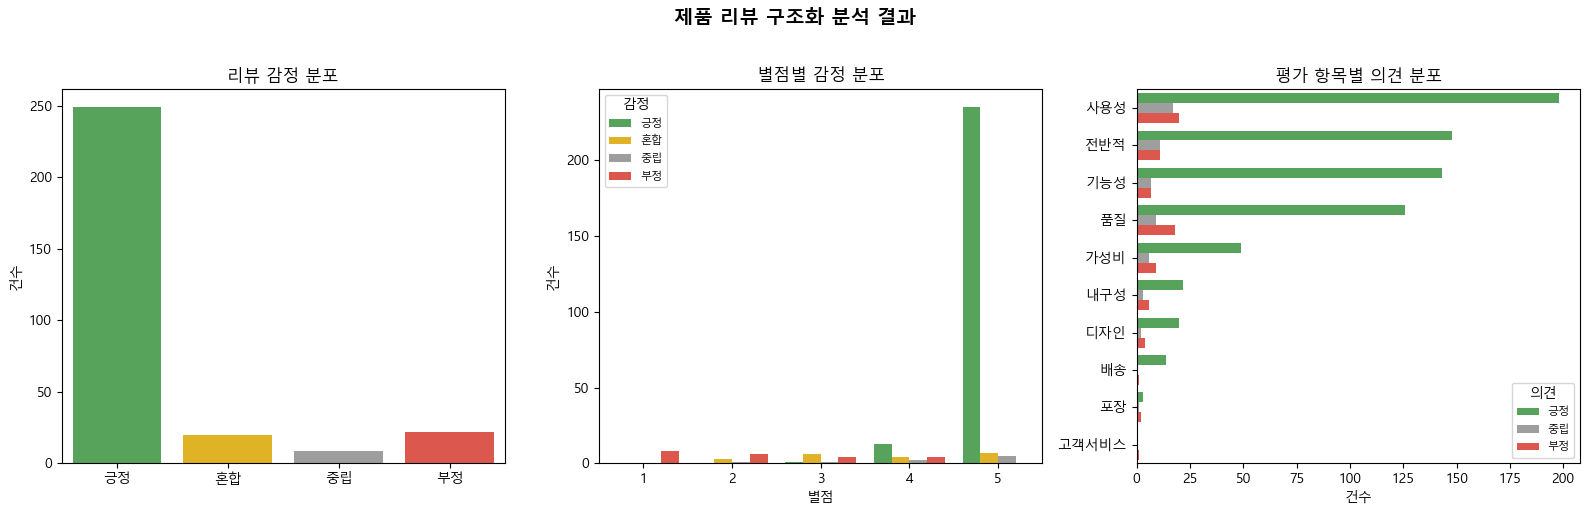

In [4]:
# aspects(중첩 리스트)를 플랫하게 펼칩니다
all_aspects = []
for row in analyzed_reviews:
    for asp in row['aspects']:
        all_aspects.append(asp)
df_aspects = pd.DataFrame(all_aspects)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) 리뷰 감정 분포
sentiment_order = ['긍정', '혼합', '중립', '부정']
sentiment_vals = [s for s in sentiment_order if s in df_analysis['overall_sentiment'].values]
sentiment_colors = {'긍정': '#4CAF50', '혼합': '#FFC107', '중립': '#9E9E9E', '부정': '#F44336'}
sns.countplot(
    data=df_analysis, x='overall_sentiment', order=sentiment_vals,
    palette=[sentiment_colors[s] for s in sentiment_vals], ax=axes[0]
)
axes[0].set_title('리뷰 감정 분포')
axes[0].set_xlabel('')
axes[0].set_ylabel('건수')

# 2) 별점별 감정 분포 (교차 분석)
sns.countplot(
    data=df_analysis, x='rating', hue='overall_sentiment',
    hue_order=sentiment_vals,
    palette=sentiment_colors, ax=axes[1]
)
axes[1].set_title('별점별 감정 분포')
axes[1].set_xlabel('별점')
axes[1].set_ylabel('건수')
axes[1].legend(title='감정', fontsize=8)

# 3) 평가 항목별 의견 분포
opinion_order = ['긍정', '중립', '부정']
opinion_vals = [o for o in opinion_order if o in df_aspects['sentiment'].values]
opinion_colors = {'긍정': '#4CAF50', '중립': '#9E9E9E', '부정': '#F44336'}
aspect_order = df_aspects['aspect'].value_counts().index.tolist()
sns.countplot(
    data=df_aspects, y='aspect', hue='sentiment',
    order=aspect_order, hue_order=opinion_vals,
    palette=opinion_colors, ax=axes[2]
)
axes[2].set_title('평가 항목별 의견 분포')
axes[2].set_xlabel('건수')
axes[2].set_ylabel('')
axes[2].legend(title='의견', fontsize=8)

plt.suptitle('제품 리뷰 구조화 분석 결과', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

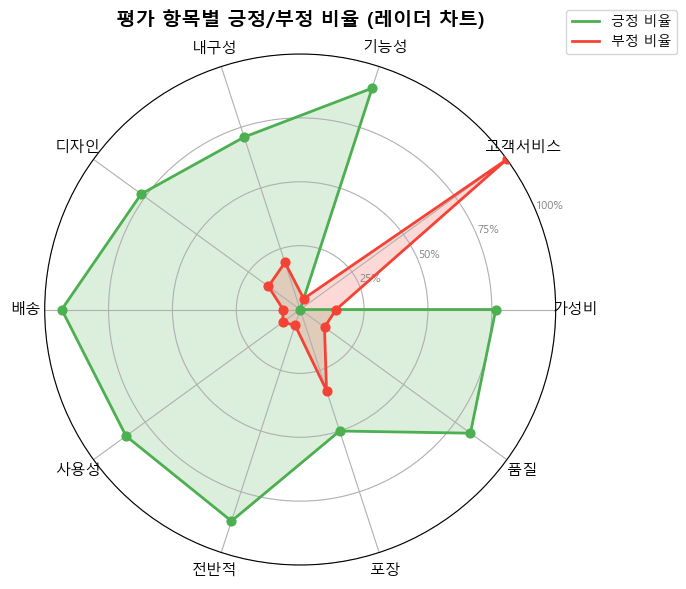

In [5]:
# =============================================================================
#  레이더 차트: 평가 항목별 긍정/부정 비율
# =============================================================================
import numpy as np

# 항목별 긍정/부정/중립 건수 집계
aspect_stats = df_aspects.groupby(['aspect', 'sentiment']).size().unstack(fill_value=0)

# 전체 항목 목록 (데이터에 존재하는 것만)
aspects_list = aspect_stats.index.tolist()
n_aspects = len(aspects_list)

if n_aspects >= 3:  # 레이더 차트는 최소 3개 항목이 필요합니다
    # 긍정/부정 비율 계산
    total_per_aspect = aspect_stats.sum(axis=1)
    positive_ratio = (aspect_stats.get('긍정', 0) / total_per_aspect).values
    negative_ratio = (aspect_stats.get('부정', 0) / total_per_aspect).values

    # 레이더 차트 각도 계산
    angles = np.linspace(0, 2 * np.pi, n_aspects, endpoint=False).tolist()
    angles += angles[:1]  # 닫힌 다각형을 위해 첫 값 반복

    positive_ratio = np.append(positive_ratio, positive_ratio[0])
    negative_ratio = np.append(negative_ratio, negative_ratio[0])

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    # 긍정 비율 (초록)
    ax.fill(angles, positive_ratio, alpha=0.2, color='#4CAF50')
    ax.plot(angles, positive_ratio, color='#4CAF50', linewidth=2, label='긍정 비율')
    ax.scatter(angles[:-1], positive_ratio[:-1], color='#4CAF50', s=40, zorder=5)

    # 부정 비율 (빨강)
    ax.fill(angles, negative_ratio, alpha=0.2, color='#F44336')
    ax.plot(angles, negative_ratio, color='#F44336', linewidth=2, label='부정 비율')
    ax.scatter(angles[:-1], negative_ratio[:-1], color='#F44336', s=40, zorder=5)

    # 축 라벨 설정
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(aspects_list, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='grey')

    ax.set_title('평가 항목별 긍정/부정 비율 (레이더 차트)',
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print(f"레이더 차트를 그리려면 최소 3개 항목이 필요합니다 (현재: {n_aspects}개)")

### 결과 저장

**실습 (6)**
- 분석 결과를 JSON 파일로 저장합니다.
- 이 파일은 다음 노트북(실전_1_2)에서 제품 비교 분석의 입력 데이터로 사용됩니다.

In [6]:
# =============================================================================
#  분석 결과 JSON 저장 (outputs 폴더)
# =============================================================================
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

output_filename = output_dir / "product_review_analysis.json"

# DataFrame을 JSON으로 저장
df_analysis.to_json(output_filename, orient='records', force_ascii=False, indent=2)

print(f"분석 결과 저장 완료")
print(f"  파일명: {output_filename}")
print(f"  저장된 리뷰 수: {len(df_analysis)}개")
print()
print("다음 단계: 실전_1_2_제품비교_리뷰분석.ipynb 에서 이 파일을 로드하여 제품 비교 분석을 진행합니다.")

분석 결과 저장 완료
  파일명: outputs\product_review_analysis.json
  저장된 리뷰 수: 300개

다음 단계: 실전_1_2_제품비교_리뷰분석.ipynb 에서 이 파일을 로드하여 제품 비교 분석을 진행합니다.
